In [ ]:
!pip install nltk
!pip install textblob

In [ ]:
import json
import nltk
import string
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
with open("intents.json", "r", encoding="utf-8") as file:
    data = json.load(file)

print("Intents loaded:", len(data["intents"]))

Intents loaded: 6


In [ ]:
stop_words = set(stopwords.words("english"))

In [ ]:
bm_stopwords = {"yang", "dan", "itu", "ini", "saya", "awak"}
stop_words = stop_words.union(bm_stopwords)

In [ ]:
fashion_slang = {
    "tee": "tshirt",
    "fit": "outfit",
    "coords": "matching set",
    "ootd": "outfit of the day",
    "kicks": "shoes",
    "denim": "jeans"
}

def replace_fashion_slang(text):
    words = text.split()
    return " ".join(
        fashion_slang[word] if word in fashion_slang else word
        for word in words
    )

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Normalize fashion slang
    for slang, normal in fashion_slang.items():
        text = text.replace(slang, normal)

    # 3. Remove punctuation (cleaner than filtering tokens)
    text = re.sub(rf"[{string.punctuation}]", "", text)

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Remove stopwords & lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    return tokens



In [ ]:
processed_data = []

for intent in data["intents"]:
    tag = intent["tag"]
    for pattern in intent["patterns"]:
        tokens = preprocess_text(pattern)
        processed_data.append(
            {"intent": tag, "original_text": pattern, "processed_tokens": tokens}
        )

In [ ]:
for item in processed_data[:10]:
    print(item)


{'intent': 'greeting', 'original_text': 'Hi', 'processed_tokens': ['hi']}
{'intent': 'greeting', 'original_text': 'Hello', 'processed_tokens': ['hello']}
{'intent': 'greeting', 'original_text': 'Hey', 'processed_tokens': ['hey']}
{'intent': 'greeting', 'original_text': 'Good morning', 'processed_tokens': ['good', 'morning']}
{'intent': 'greeting', 'original_text': 'Good evening', 'processed_tokens': ['good', 'evening']}
{'intent': 'fashion_start', 'original_text': 'I need fashion help', 'processed_tokens': ['need', 'fashion', 'help']}
{'intent': 'fashion_start', 'original_text': 'Yes', 'processed_tokens': ['yes']}
{'intent': 'fashion_start', 'original_text': 'What should I wear?', 'processed_tokens': ['wear']}
{'intent': 'fashion_start', 'original_text': 'Help me dress', 'processed_tokens': ['help', 'dress']}
{'intent': 'fashion_start', 'original_text': 'recommend an outfit', 'processed_tokens': ['recommend', 'outoutfit']}


Dialog Management using Hybrid Ml-based + Rule-based

In [ ]:
import numpy as np
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

# --- 1. Create Vocabulary and Classes ---
all_words = []
classes = []

# Collect all unique words and intent tags from processed_data
for item in processed_data:
    all_words.extend(item['processed_tokens'])
    if item['intent'] not in classes:
        classes.append(item['intent'])

# Remove duplicates and sort
all_words = sorted(list(set(all_words)))
classes = sorted(list(set(classes)))

print(f"Unique words (Vocabulary): {len(all_words)}")
print(f"Classes (Intents): {classes}")

# --- 2. Create Training Data (Bag of Words) ---
training = []
output_empty = [0] * len(classes)

for item in processed_data:
    bag = []
    tokens = item['processed_tokens']

    # Create the Bag of Words array: 1 if word exists, 0 if not
    for w in all_words:
        bag.append(1) if w in tokens else bag.append(0)

    # Create the output array (One-hot encoding for the intent)
    output_row = list(output_empty)
    output_row[classes.index(item['intent'])] = 1

    training.append([bag, output_row])

# Shuffle and convert to NumPy array for TensorFlow
random.shuffle(training)
training = np.array(training, dtype=object)

# Split into Features (X) and Labels (Y)
train_x = list(training[:, 0])
train_y = list(training[:, 1])

Unique words (Vocabulary): 41
Classes (Intents): ['fashion_slang', 'fashion_start', 'goodbye', 'greeting', 'result', 'trend_query']


In [ ]:
# --- 3. Build the Neural Network ---
model = Sequential()
# Input Layer: 128 neurons, input shape is the size of our vocabulary
model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5)) # Prevents overfitting
# Hidden Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
# Output Layer: Number of neurons equals number of intents (Softmax for probability)
model.add(Dense(len(train_y[0]), activation='softmax'))

# Compile the model
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

# --- 4. Train the Model ---
# epochs=200 means it goes through the data 200 times
hist = model.fit(np.array(train_x), np.array(train_y), epochs=200, batch_size=5, verbose=0)

print("Model trained.")
model.save('chatbot_model.keras') # Save the model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model trained.


Model Accuracy: 100.00%

--- Detailed Classification Report ---
               precision    recall  f1-score   support

fashion_slang       1.00      1.00      1.00         5
fashion_start       1.00      1.00      1.00        11
      goodbye       1.00      1.00      1.00         8
     greeting       1.00      1.00      1.00         5
       result       1.00      1.00      1.00         5
  trend_query       1.00      1.00      1.00         4

     accuracy                           1.00        38
    macro avg       1.00      1.00      1.00        38
 weighted avg       1.00      1.00      1.00        38



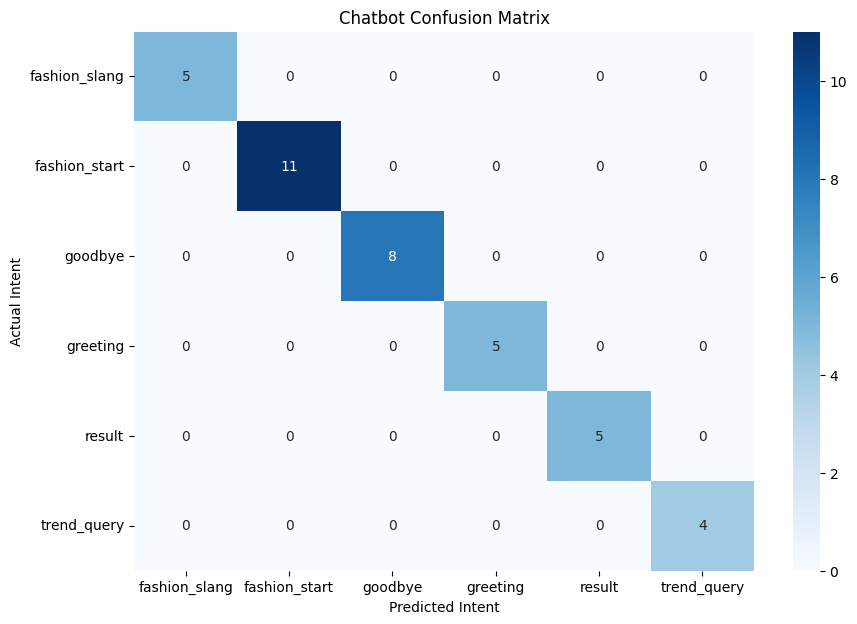

In [ ]:
#evaluate the model by calculating the metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

loss, accuracy = model.evaluate(np.array(train_x), np.array(train_y), verbose=0)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Make predictions on the training data
y_pred_raw = model.predict(np.array(train_x), verbose=0)
# Convert one-hot encoded true labels to class indices
y_true_classes = np.argmax(np.array(train_y), axis=1)
# Convert predicted probabilities to class indices
y_pred_classes = np.argmax(y_pred_raw, axis=1)

#confusion
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# 5. Visualizing Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Intent')
plt.ylabel('Actual Intent')
plt.title('Chatbot Confusion Matrix')
plt.show()

In [ ]:
import numpy as np
import random
from textblob import TextBlob

# --- MEMORY & STATE TRACKING ---
user_context = {
    "is_consulting": False,
    "step": 0,
    "sub_step": "", # New: tracks the color branch
    "data": {
        "name": "", "gender": "", "weight": 0, "height": 0,
        "size": "", "occasion": "", "color": "", "undertone": ""
    }
}
# Color Palettes Dictionary
palettes = {
    "warm": "olive green, warm reds, oranges, golden yellows, peach, coral, and rich browns",
    "cool": "cool blues, purples, pinks, magenta, true white, black, navy, and emerald",
    "neutral": "soft blues, blush pinks, jade greens, and charcoal"
}

# Data preprocessing of message
def clean_up_sentence(sentence):
    return preprocess_text(sentence)

# BoW vectorization
def bow(sentence, words):
    # Convert user input to Bag of Words
    sentence_words = clean_up_sentence(sentence)
    bag = [0] * len(words)
    for s in sentence_words:
        for i, w in enumerate(words):
            if w == s:
                bag[i] = 1
    return np.array(bag)

# Intents Prediction
def predict_class(sentence):
    # 1. Convert input to numbers
    p = bow(sentence, all_words)
    # 2. Predict using the model
    res = model.predict(np.array([p]), verbose=0)[0]

    # 3. Filter out low probability results (Threshold 25%)
    ERROR_THRESHOLD = 0.25
    results = [[i, r] for i, r in enumerate(res) if r > ERROR_THRESHOLD]

    # 4. Sort by highest probability
    results.sort(key=lambda x: x[1], reverse=True)

    return_list = []
    for r in results:
        return_list.append({"intent": classes[r[0]], "probability": str(r[1])})
    return return_list

# Fallback
def get_response(intents_list, intents_json):
    # If the model didn't find a high-confidence intent
    if not intents_list:
        return "I'm sorry, I don't understand."

    tag = intents_list[0]['intent']
    list_of_intents = intents_json['intents']

    # Find the matching intent in the JSON and return a random response
    for i in list_of_intents:
        if i['tag'] == tag:
            result = random.choice(i['responses'])
            break
    return result

# The Clothing Size 👕
def calculate_size(weight, height):
    # Simple logic for Size Calculation
    bmi = weight / ((height/100)**2)
    if bmi < 18.5: return "Small (S)"
    elif 18.5 <= bmi < 25: return "Medium (M)"
    elif 25 <= bmi < 30: return "Large (L)"
    else: return "Extra Large (XL)"

# Core : The Fashion Recommendation 👗
def get_fashion_recommendation(data):
    occ = data['occasion'].lower()
    col = data['color'].lower()
    gen = data['gender'].lower()
    size = data['size']
    name = data['name']

    fashion_rules = {
        "formal": {
            "male": [
                "a tailored navy suit",
                "a modern double-breasted suit",
                "a classic tuxedo with minimalist accessories"
            ],
            "female": [
                "a sophisticated silk gown",
                "a satin evening dress with statement heels",
                "a tailored pantsuit with modern cuts"
            ]
        },
        "wedding": {
            "male": [
                "a tuxedo",
                "a traditional suit with modern tailoring"
            ],
            "female": [
                "an elegant maxi dress",
                "a lace gown with contemporary styling"
            ]
        },
        "work": {
            "male": [
                "smart trousers with a blazer",
                "a fitted shirt with tailored chinos"
            ],
            "female": [
                "a blouse with tailored pants",
                "a midi skirt paired with a structured blazer"
            ]
        },
        "casual": {
            "male": [
                "high-waisted jeans with a relaxed linen shirt",
                "oversized t-shirt with straight-cut jeans"
            ],
            "female": [
                "wide-leg jeans with a cropped top",
                "a relaxed shirt dress with sneakers"
            ]
        },
        "party": {
            "male": [
                "a slim-fit shirt with dark jeans",
                "a long sleeve jacket"
            ],
            "female": [
                "a mini dress with bold accessories",
                "a co-ord set following current trends"
            ]
        }
    }

    # Find matching occasion
    suggestions = []
    for key in fashion_rules:
        if key in occ:
            gender_key = "male" if "male" in gen else "female"
            suggestions = fashion_rules[key].get(gender_key, [])
            break

    if not suggestions:
        return f"Sorry {name}, I couldn't find fashion suggestions for that occasion yet."

    # Build chatbot-friendly response
    rec = (
        f"Okay {name}, your size is {size}, here are some "
        f"{occ.capitalize()} outfit ideas in {col} you can choose from:\n"
    )

    for i, outfit in enumerate(suggestions, start=1):
        rec += f"{i}. {outfit} in {col}\n"

    return rec


In [ ]:
import gradio as gr
import numpy as np
import random
import json
from textblob import TextBlob

# --- 1. SET UP GLOBAL VARIABLES ---
try:
    current_data = data
    current_model = model
    current_words = all_words
    current_classes = classes
except NameError:
    print("❌ ERROR")

# --- 2. INTERFACE LOGIC ---
def reset_context():
    return {
        "is_consulting": False,
        "step": 0,
        "sub_step": "",
        "data": {"name": "", "gender": "", "weight": 0, "height": 0, "size": "", "occasion": "", "color": "", "undertone": ""}
    }
# Rule-based
def chat_engine(message, history, state):
    if state is None:
        state = reset_context()

    msg = message.strip()
    if not msg:
        return "Please say something!", state

    if state["is_consulting"]:
        step = state["step"]
        if step == 0:
            state["data"]["name"] = msg
            state["step"] += 1
            return f"Nice to meet you, {msg}! Are you Male or Female?", state
        elif step == 1:
            state["data"]["gender"] = msg
            state["step"] += 1
            return "Got it. What is your weight in kg?", state
        elif step == 2:
            try:
                state["data"]["weight"] = float(msg)
                state["step"] += 1
                return "And what is your height in cm?", state
            except: return "Please enter a number for weight (e.g. 70).", state
        elif step == 3:
            try:
                state["data"]["height"] = float(msg)
                state["data"]["size"] = calculate_size(state["data"]["weight"], state["data"]["height"])
                state["step"] += 1
                return f"Your calculated size is {state['data']['size']}. What is the occasion? (Formal, Casual, Wedding, Work, Party)", state
            except: return "Please enter a number for height (e.g. 175).", state
        elif step == 4:
            state["data"]["occasion"] = msg
            state["step"] += 1
            return "Do you already have a preferred color in mind? (Yes/No)", state
        elif step == 5:
            if "yes" in msg.lower():
                state["sub_step"] = "direct_color"
                state["step"] += 1
                return "Great! Which color do you prefer?", state
            else:
                state["sub_step"] = "ask_undertone"
                state["step"] += 1
                return "No problem! Is your skin undertone Warm, Cool, or Neutral?", state
        elif step == 6:
            if state["sub_step"] == "direct_color":
                state["data"]["color"] = msg
                res = get_fashion_recommendation(state["data"])
                state.update(reset_context())
                return res, state
            elif state["sub_step"] == "ask_undertone":
                choice = msg.lower()
                if choice in palettes:
                    state["data"]["undertone"] = choice
                    state["sub_step"] = "pick_from_palette"
                    return f"Based on your {choice} undertone, these colors look best: {palettes[choice]}. Which one would you like?", state
                else: return "Please choose Warm, Cool, or Neutral.", state
            elif state["sub_step"] == "pick_from_palette":
                state["data"]["color"] = msg
                res = get_fashion_recommendation(state["data"])
                state.update(reset_context())
                return res, state
    else:
        ints = predict_class(msg)
        if not ints:
            return "I'm not sure I understand. Could you rephrase that?", state
        tag = ints[0]['intent']
        if tag == "fashion_start":
            state["is_consulting"] = True
            return get_response(ints, current_data), state
        res = get_response(ints, current_data)
        blob = TextBlob(msg)
        if blob.sentiment.polarity > 0:
            res += " 😊"
        return res, state

# --- 3.Purple UI ---
with gr.Blocks(theme=gr.themes.Soft(primary_hue="purple", secondary_hue="indigo"), css="""
    .gradio-container { background-color: #2E0854; }
    .header-box { text-align: center; padding: 20px; background: linear-gradient(135deg, #D1C4E9 0%, #D1C4E9 100%); border-radius: 20px; margin-bottom: 20px; }
    #chat-box { border-radius: 15px !important; background: white; box-shadow: 0 10px 25px rgba(0,0,0,0.05) !important; }


    .gr-button-project, .gallery-item { color: white !important; }
    .examples-container button { color: white !important; background-color: rgba(255,255,255,0.1) !important; }

    /* Buang scroll/arrow kalau ada pada textbox */
    textarea { overflow: hidden !important; resize: none !important; }
    .gr-samples-label { color: #D1C4E9 !important; }
""") as demo:

    with gr.Column(elem_classes="header-box"):
        gr.Markdown("""
        # 👗👔 **WeFashion**
        ### *Your Premium Personal Stylist*
        *Helping you find the perfect fit with a touch of elegance.*
        """)

    with gr.Column():
        chatbot = gr.Chatbot(
            label="Style Consultant",
            height=500,
            bubble_full_width=False,
            elem_id="chat-box",
            avatar_images=(None, "https://cdn-icons-png.flaticon.com/512/4140/4140037.png")
        )


        with gr.Row():
            msg_input = gr.Textbox(
                show_label=False,
                placeholder="Type 'hi' or 'help me with fashion'...",
                scale=8,
                container=False
            )
            submit_btn = gr.Button("Send ✨", variant="primary", scale=2)
            clear_btn = gr.Button("Clear Chat 🗑️", variant="secondary", scale=1)

        gr.Examples(
            examples=["Hi!", "I want a fashion consultation", "Help me with an outfit"],
            inputs=msg_input,
            label="Quick Starts"
        )

    state_holder = gr.State()

    def respond(message, chat_history, state):
        if not message: return "", chat_history, state
        bot_message, new_state = chat_engine(message, chat_history, state)
        chat_history.append((message, bot_message))
        return "", chat_history, new_state

    def clear_chat():
        return [], reset_context()

    submit_btn.click(respond, [msg_input, chatbot, state_holder], [msg_input, chatbot, state_holder])
    msg_input.submit(respond, [msg_input, chatbot, state_holder], [msg_input, chatbot, state_holder])
    clear_btn.click(clear_chat, None, [chatbot, state_holder])

demo.launch(share=True)

/tmp/ipython-input-564529921.py:102: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="purple", secondary_hue="indigo"), css="""
/tmp/ipython-input-564529921.py:102: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="purple", secondary_hue="indigo"), css="""
/tmp/ipython-input-564529921.py:124: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipython-input-564529921.py:124: DeprecationWarning: The 'bu

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d74210b6b328ac35cc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
